In [2]:
import pandas as pd
df = pd.read_excel("Cleaned_Dataset.xlsx")


In [3]:
print(df.shape)        # rows, columns
print(df.info())       # data types
print(df.head())       # first 5 rows

(1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(

In [4]:
print(df.describe())   # gives mean, min, max, std, etc. for number columns
print(df.median(numeric_only=True))

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558
Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64


In [5]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalPrice'] < Q1 - 1.5*IQR) | (df['TotalPrice'] > Q3 + 1.5*IQR)]
print(outliers)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107 2023-03-27     C16775  Printer         5     670.75   
326   ORD200326 2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328 2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469 2023-11-26     C13877    Chair         5     676.98   
632   ORD200632 2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789 2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065 2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122 2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card    Returned    TRK98353867            5   
328      546 Main St        Online   Cancelled    TRK89401624            7   
469      893 Main St          Cash   Cancelled  

In [6]:
print(df.corr(numeric_only=True))

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


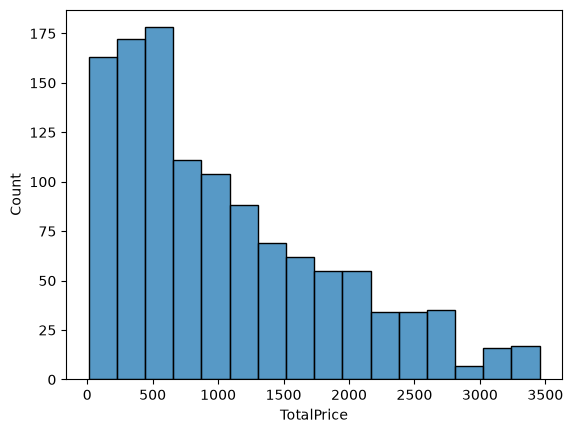

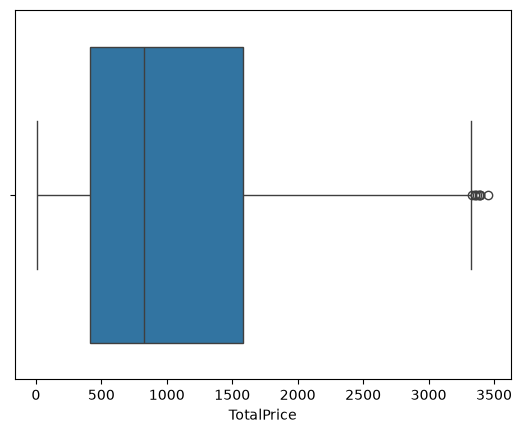

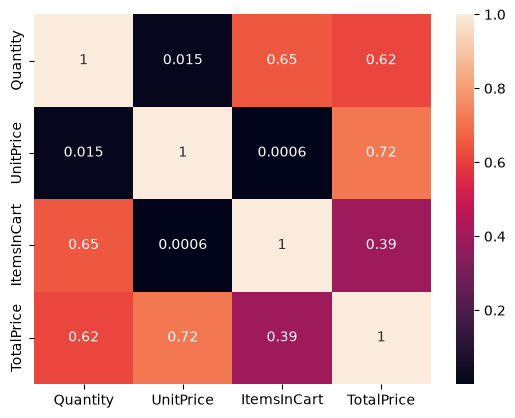

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['TotalPrice'])      # distribution shape
plt.show()

sns.boxplot(x=df['TotalPrice'])     # outliers
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)   # correlation
plt.show()